# NTP ICE 급성 경구 독성 이진 분류 모델

**데이터**: NTP ICE - Acute Oral  
**목표**: LD50 ≤ 300 mg/kg → **독성(1)**, LD50 > 300 mg/kg → **비독성(0)**  
**분류 기준**: GHS Category 1~3 (Fatal/Toxic) vs Category 4~5+ (Harmful/Not classified)

## 전체 파이프라인

```mermaid
flowchart LR
    A["NTP ICE Acute Oral<br/>(16,721행)"] --> B["전처리<br/>LD50 · Chemical · mg/kg<br/>염 제거 · 표준편차 필터"]
    B --> C["이진 라벨 생성<br/>LD50 ≤ 300 → 독성(1)<br/>LD50 > 300 → 비독성(0)"]
    C --> D["분자 디스크립터<br/>Morgan · ECFP6 · MACCS<br/>AtomPair · Torsion · RDKit"]
    D --> E["데이터 분할<br/>Train+Val 80%<br/>Test 20%"]
    E --> F["5-Fold Stratified CV<br/>RF · ExtraTrees · XGBoost"]
    F --> G["최종 평가<br/>BalAcc · MCC · F1 · AUC"]

    style A fill:#dbeafe,stroke:#2563eb,color:#1e3a5f
    style B fill:#fef3c7,stroke:#d97706,color:#78350f
    style C fill:#fce7f3,stroke:#db2777,color:#831843
    style D fill:#dcfce7,stroke:#16a34a,color:#14532d
    style E fill:#ede9fe,stroke:#7c3aed,color:#3b0764
    style F fill:#e0f2fe,stroke:#0284c7,color:#0c4a6e
    style G fill:#fff7ed,stroke:#ea580c,color:#7c2d12
```


## 1. 라이브러리 불러오기

In [12]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, RDKFingerprint
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              matthews_corrcoef, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한국어 폰트 설정
def _set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    return 'DejaVu Sans'

matplotlib.rcParams['font.family'] = _set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 데이터 불러오기

In [13]:
df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
print(f'원본 데이터: {df.shape}')
df.head(3)

원본 데이터: (16721, 23)


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_oral_12325,In Vivo,MIX86,Captevate 68 WDG,Captan-related-substance,NaN,NaN,1.20,Mixture,Rat,...,NaN,5.0,Unitless,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_oral_12322,In Vivo,MIX82,Captan 4L,Captan-related-substance,NaN,NaN,0.97,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_oral_12133,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.60,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN


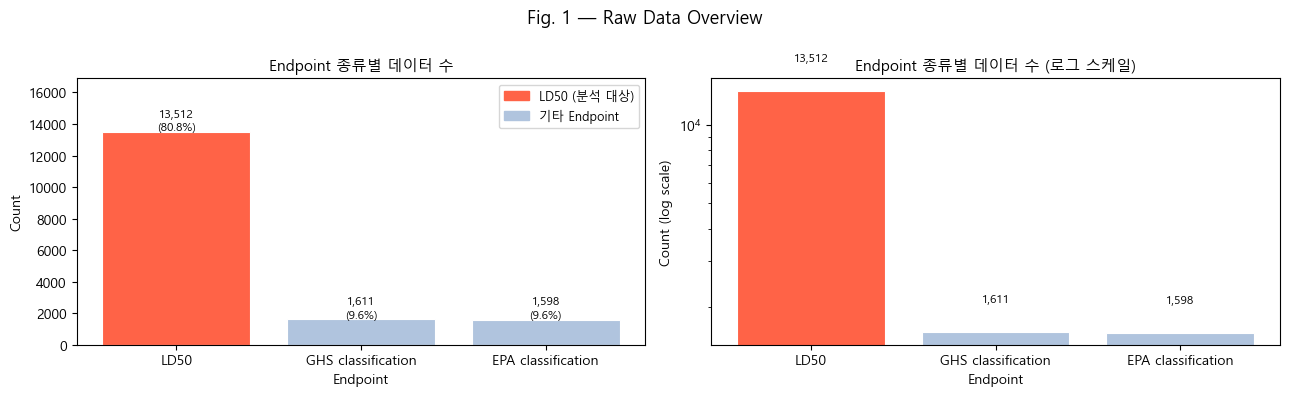

In [14]:
# Endpoint 분포 시각화
vc = df['Endpoint'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: Endpoint 분포 (LD50 강조)
colors_ep = ['tomato' if ep == 'LD50' else 'lightsteelblue' for ep in vc.index]
bars = axes[0].bar(vc.index, vc.values, color=colors_ep, edgecolor='white', linewidth=0.8)
axes[0].set_title('Endpoint 종류별 데이터 수', fontsize=11)
axes[0].set_xlabel('Endpoint')
axes[0].set_ylabel('Count')
for i, (bar, v) in enumerate(zip(bars, vc.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 80,
                 f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=8.5)
axes[0].set_ylim(0, max(vc.values) * 1.25)
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato',   label='LD50 (분석 대상)'),
    plt.Rectangle((0,0),1,1, color='lightsteelblue', label='기타 Endpoint')],
    fontsize=9, loc='upper right')

# 오른쪽: 로그 스케일 — 소수 Endpoint 가시화
colors_log = ['tomato' if ep == 'LD50' else 'lightsteelblue' for ep in vc.index]
axes[1].bar(vc.index, vc.values, color=colors_log, edgecolor='white', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Endpoint 종류별 데이터 수 (로그 스케일)', fontsize=11)
axes[1].set_xlabel('Endpoint')
axes[1].set_ylabel('Count (log scale)')
for i, v in enumerate(vc.values):
    axes[1].text(i, v * 1.3, f'{v:,}', ha='center', fontsize=8.5)

plt.suptitle('Fig. 1 — Raw Data Overview', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 1] Raw Data Overview**

- LD50이 전체 데이터의 대다수를 차지하여 이진 분류 모델 구축에 충분한 데이터량 확보
- 로그 스케일(오른쪽)에서 소수 Endpoint(GHS, EPA 등)의 분포도 확인 가능

## 3. 데이터 전처리 및 이진 라벨 생성

**전처리 단계**:
1. LD50 Endpoint만 선택
2. 단일 화학물질(Chemical), mg/kg 단위, 부등호 없는 정확한 수치만 사용
3. SMILES 결측 제거 + SaltRemover로 염 제거
4. 동일 SMILES의 log10(LD50) std > 0.5 제외 → 나머지 평균 처리
5. **이진 라벨**: LD50 ≤ 300 mg/kg → 독성(1), > 300 → 비독성(0)

In [15]:
remover = SaltRemover()

def remove_salt(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return None
        smi_clean = Chem.MolToSmiles(remover.StripMol(mol))
        return smi_clean if smi_clean else None
    except: return None

df_f = df[df['Endpoint'] == 'LD50'].copy()
print(f'LD50 필터:              {len(df_f):>6}행')

df_f = df_f[df_f['Mixture'] == 'Chemical'].copy()
print(f'Chemical 필터:          {len(df_f):>6}행')

df_f = df_f[df_f['Response_Unit'] == 'mg/kg'].copy()
print(f'mg/kg 단위 필터:        {len(df_f):>6}행')

df_f = df_f[df_f['Response_Modifier'].isna()].copy()
print(f'부등호 제거:            {len(df_f):>6}행')

df_f = df_f[df_f['SMILES'].notna()].copy()
df_f['Response'] = pd.to_numeric(df_f['Response'], errors='coerce')
df_f = df_f[df_f['Response'].notna()].copy()
print(f'유효 수치값 필터:       {len(df_f):>6}행')

df_f['SMILES_clean'] = df_f['SMILES'].apply(remove_salt)
df_f = df_f[df_f['SMILES_clean'].notna()].copy()
print(f'염 제거:                {len(df_f):>6}행')

df_f['logLD50'] = np.log10(df_f['Response'].clip(lower=0.01))
keep = df_f.groupby('SMILES_clean')['logLD50'].transform('std').fillna(0) <= 0.5
df_f = df_f[keep].copy()
print(f'표준편차 필터 (≤0.5):  {len(df_f):>6}행')

# ── 중복 SMILES 체크 ──────────────────────────────────────────────────
n_before_dedup = len(df_f)
n_unique_smiles = df_f['SMILES_clean'].nunique()
n_duplicates    = n_before_dedup - n_unique_smiles
print(f'\n[중복 SMILES 체크]')
print(f'  염 제거 후 전체 행 수   : {n_before_dedup}')
print(f'  고유 SMILES 수          : {n_unique_smiles}')
print(f'  중복 엔트리 수          : {n_duplicates}  → 동일 SMILES 평균값으로 통합')

# 동일 SMILES 평균 통합 + 라벨 생성
df_clean = (df_f.groupby('SMILES_clean')['logLD50'].mean()
              .reset_index().rename(columns={'SMILES_clean': 'SMILES'}))
df_clean['LD50']  = 10 ** df_clean['logLD50']
df_clean['label'] = (df_clean['LD50'] <= 300).astype(int)

print(f'\n최종 데이터: {len(df_clean)}개 분자')
print(df_clean['label'].value_counts()
      .rename({0: '비독성 (LD50>300)', 1: '독성 (LD50≤300)'}).to_string())
print(f'독성 비율: {df_clean["label"].mean():.1%}')

LD50 필터:               13512행
Chemical 필터:           12207행
mg/kg 단위 필터:         12207행
부등호 제거:              8757행
유효 수치값 필터:         8622행
염 제거:                  8597행
표준편차 필터 (≤0.5):    8321행

최종 데이터: 6388개 분자
label
비독성 (LD50>300)    4679
독성 (LD50≤300)     1709
독성 비율: 26.8%


> 16,721행 → **6,388개 분자** (최종 사용률 38.2%)  
> 부등호 처리(`>`, `<`)로 약 3,800행 제거가 가장 큰 필터 단계이며, 이는 정확한 LD50 수치가 있는 데이터만 사용함을 의미  
> 독성 비율 **26.8%** (비독성 73.2%) → 약 2.74:1 클래스 불균형 존재 → Balanced Accuracy 및 scale_pos_weight 사용 근거

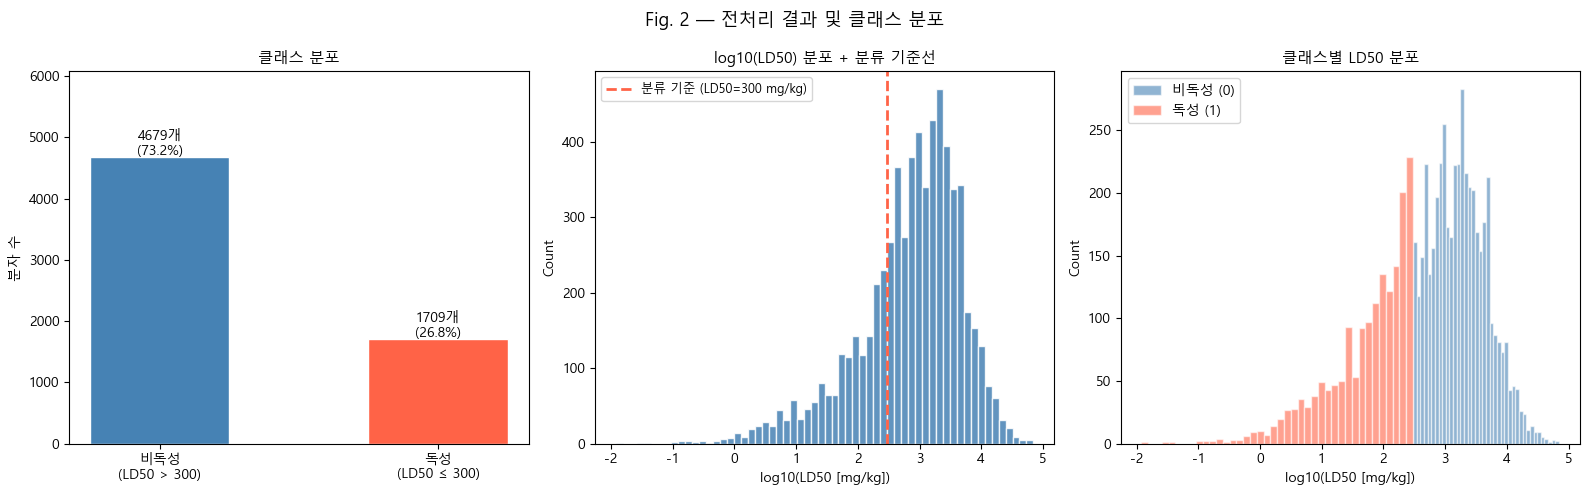

In [16]:
# 전처리 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 왼쪽: 클래스 분포
counts = df_clean['label'].value_counts().sort_index()
bars = axes[0].bar(['비독성\n(LD50 > 300)', '독성\n(LD50 ≤ 300)'],
                    [counts[0], counts[1]],
                    color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, v in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v}개\n({v/len(df_clean):.1%})', ha='center', fontsize=10)
axes[0].set_title('클래스 분포', fontsize=11)
axes[0].set_ylabel('분자 수')
axes[0].set_ylim(0, max(counts) * 1.3)

# 가운데: log10(LD50) 분포 + 기준선
axes[1].hist(df_clean['logLD50'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].axvline(np.log10(300), color='tomato', linewidth=2,
                linestyle='--', label='분류 기준 (LD50=300 mg/kg)')
axes[1].set_xlabel('log10(LD50 [mg/kg])')
axes[1].set_ylabel('Count')
axes[1].set_title('log10(LD50) 분포 + 분류 기준선', fontsize=11)
axes[1].legend(fontsize=9)

# 오른쪽: 클래스별 분포 비교
for label, color, name in [(0, 'steelblue', '비독성 (0)'), (1, 'tomato', '독성 (1)')]:
    axes[2].hist(df_clean[df_clean['label'] == label]['logLD50'],
                 bins=40, alpha=0.6, color=color, edgecolor='white', label=name)
axes[2].set_xlabel('log10(LD50 [mg/kg])')
axes[2].set_ylabel('Count')
axes[2].set_title('클래스별 LD50 분포', fontsize=11)
axes[2].legend()

plt.suptitle('Fig. 2 — 전처리 결과 및 클래스 분포', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 2] 전처리 결과 및 클래스 분포**

- **왼쪽 (클래스 분포)**: 비독성 4,679개(73.2%) vs 독성 1,709개(26.8%) — 2.74:1 불균형. 이 비율을 XGBoost의 `scale_pos_weight=2.74`로 직접 보정
- **가운데 (LD50 분포)**: 분포 피크가 log10(LD50) ≈ 2.7~3.0 구간에 집중되어 있고, 분류 기준선(log10(300) ≈ 2.48)이 피크 왼쪽에 위치 → 기준선 근처 분자가 많아 경계 분류 난이도 높음
- **오른쪽 (클래스별 분포)**: 두 클래스가 log10 ≈ 1.5~3.5 구간에서 크게 겹침. 이 겹침 구간이 모델 오분류가 집중되는 영역이며, Sensitivity(0.550)가 낮은 원인

## 4. 분자 디스크립터 추출

SMILES를 머신러닝 입력 벡터로 변환합니다.

| 디스크립터 | 차원 | 특징 |
|---|---|---|
| Morgan FP (ECFP4) | 2048 | 원자 주변 환경을 반경 2로 인코딩 |
| ECFP6 | 2048 | 반경 3으로 더 넓은 환경 탐색 |
| MACCS Keys | 166 | 166개 사전 정의된 구조적 키 |
| Atom Pair FP | 2048 | 원자쌍의 종류 + 거리 인코딩 |
| Topological Torsion FP | 2048 | 4원자 연속 경로의 비틀림 패턴 |
| RDKit Descriptors | ~200 | MW, LogP, TPSA 등 물리화학적 특성 |

In [17]:
def mol_from_smiles(smi): return Chem.MolFromSmiles(smi)
def morgan_fp(mol): return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
def ecfp6(mol):    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 3, 2048))
def maccs_fp(mol): return np.array(MACCSkeys.GenMACCSKeys(mol))
def ap_fp(mol):    return np.array(rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=2048))
def tor_fp(mol):   return np.array(rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=2048))

def rdkit_desc(mol):
    vals = []
    for _, fn in Descriptors.descList:
        try:
            v = float(fn(mol))
            vals.append(v if np.isfinite(v) else 0.0)
        except: vals.append(0.0)
    return np.array(vals)

mols = df_clean['SMILES'].apply(mol_from_smiles)
valid_mask = mols.notna()
df_desc    = df_clean[valid_mask].copy().reset_index(drop=True)
mols_valid = mols[valid_mask].reset_index(drop=True)

print('디스크립터 계산 중...')
X_morgan = np.stack(mols_valid.apply(morgan_fp))
X_ecfp6  = np.stack(mols_valid.apply(ecfp6))
X_maccs  = np.stack(mols_valid.apply(maccs_fp))
X_ap     = np.stack(mols_valid.apply(ap_fp))
X_tor    = np.stack(mols_valid.apply(tor_fp))
X_phys   = np.stack(mols_valid.apply(rdkit_desc))
y        = df_desc['label'].values

print(f'유효 분자 수  : {len(df_desc)}')
print(f'Morgan FP    : {X_morgan.shape}')
print(f'MACCS Keys   : {X_maccs.shape}')
print(f'RDKit Desc   : {X_phys.shape}')
print('완료')

디스크립터 계산 중...


[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerator
[13:04:00] DEPRECATION WARNING: please use MorganGenerat

유효 분자 수  : 6388
Morgan FP    : (6388, 2048)
MACCS Keys   : (6388, 167)
RDKit Desc   : (6388, 217)
완료


In [ ]:
# ── Descriptor CSV 저장 ──────────────────────────────────────────────────
# 출력: final_dataset_descriptors.csv
# 컬럼 구성: SMILES | label | MorganFP_0..2047 | MACCS_0..165 | RDKitDesc_0..N-1

desc_names = [name for name, _ in Descriptors.descList]

df_morgan = pd.DataFrame(X_morgan, columns=[f'Morgan_{i}' for i in range(X_morgan.shape[1])])
df_maccs  = pd.DataFrame(X_maccs,  columns=[f'MACCS_{i}'  for i in range(X_maccs.shape[1])])
df_phys   = pd.DataFrame(X_phys,   columns=desc_names[:X_phys.shape[1]])

df_export = pd.concat([
    df_desc[['SMILES', 'label']].reset_index(drop=True),
    df_morgan, df_maccs, df_phys
], axis=1)

df_export.to_csv('final_dataset_descriptors.csv', index=False)

print(f'저장 완료: final_dataset_descriptors.csv')
print(f'  행 수     : {len(df_export)} (분자)')
print(f'  열 수     : {df_export.shape[1]} (SMILES + label + descriptor)')
print(f'  독성 라벨  : {df_export["label"].sum()}개  /  비독성: {(df_export["label"]==0).sum()}개')
print(df_export.iloc[:3, :6])

## 5. 데이터 분할 및 화학 공간 분석

In [18]:
idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y)
y_trainval = y[idx_trainval]
y_test     = y[idx_test]

print(f'Train+Val : {len(idx_trainval)}개  독성={y_trainval.sum()} ({y_trainval.mean():.1%})')
print(f'Test      : {len(idx_test)}개  독성={y_test.sum()} ({y_test.mean():.1%})')

Train+Val : 5110개  독성=1367 (26.8%)
Test      : 1278개  독성=342 (26.8%)


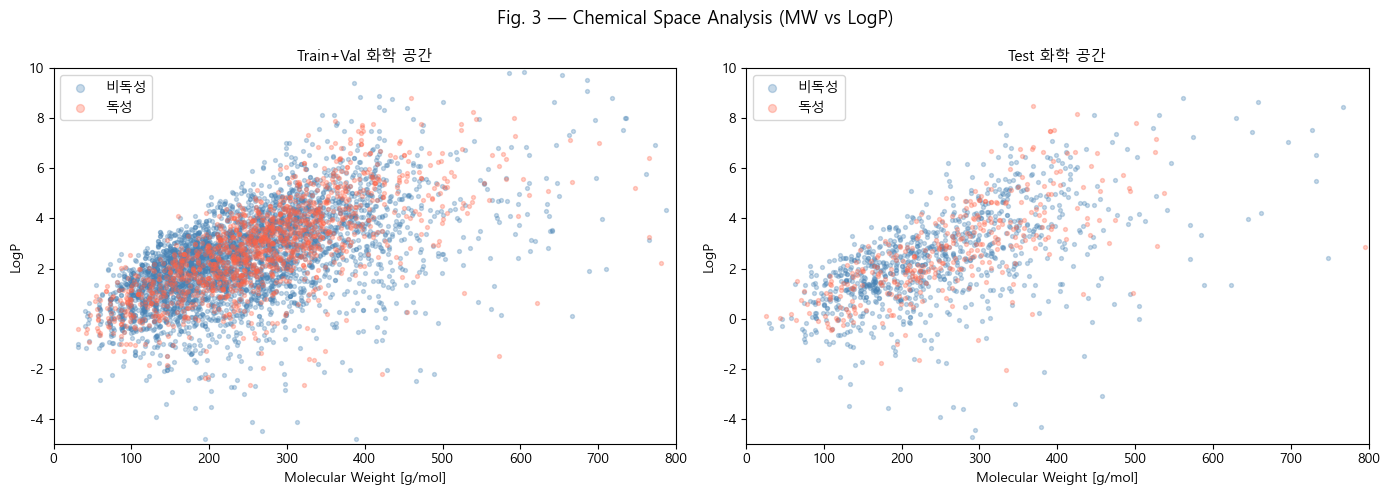

In [19]:
# 화학 공간 시각화 (MW vs LogP)
mw   = mols_valid.apply(lambda m: Descriptors.MolWt(m))
logp = mols_valid.apply(lambda m: Descriptors.MolLogP(m))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx_set, title in [(axes[0], idx_trainval, 'Train+Val'),
                            (axes[1], idx_test,     'Test')]:
    mask = np.zeros(len(y), dtype=bool)
    mask[idx_set] = True
    for label, color, name in [(0, 'steelblue', '비독성'), (1, 'tomato', '독성')]:
        sel = mask & (y == label)
        ax.scatter(mw[sel], logp[sel], c=color, alpha=0.3, s=8, label=name)
    ax.set_xlabel('Molecular Weight [g/mol]')
    ax.set_ylabel('LogP')
    ax.set_title(f'{title} 화학 공간', fontsize=11)
    ax.legend(markerscale=2)
    ax.set_xlim(0, 800)
    ax.set_ylim(-5, 10)

plt.suptitle('Fig. 3 — Chemical Space Analysis (MW vs LogP)', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 3] Chemical Space Analysis (MW vs LogP)**

- Train과 Test의 분포 패턴이 시각적으로 거의 동일 → Stratified Split의 유효성 확인
- 독성 분자(빨간 점)는 MW 100~400 g/mol, LogP -2~4 구간에 집중되는 경향
- 비독성 분자(파란 점)는 고분자량(MW > 400) 영역까지 넓게 분포 → 더 다양한 화학 구조 포함

## 6. 디스크립터 정제

RDKit Descriptors의 **분산=0 특성**과 **|r|>0.95 중복 특성**을 Train+Val 기준으로 제거합니다.  
⚠️ 필터를 Train+Val에서만 학습하고 Test에 동일하게 적용하여 정보 누수를 방지합니다.

In [20]:
# ① 분산=0 제거
var_sel   = VarianceThreshold(threshold=0.0)
X_phys_tv = var_sel.fit_transform(X_phys[idx_trainval])
n_before  = X_phys.shape[1]
print(f'분산=0 제거: {n_before} → {X_phys_tv.shape[1]}개')

# ② 상관 |r|>0.95 제거
corr  = np.corrcoef(X_phys_tv.T)
upper = np.triu(np.abs(corr), k=1)
drop  = set(int(i) for i in np.where((upper > 0.95).any(axis=0))[0])
keep  = [i for i in range(X_phys_tv.shape[1]) if i not in drop]
X_phys_clean = var_sel.transform(X_phys)[:, keep]
print(f'상관 필터:   {X_phys_tv.shape[1]} → {len(keep)}개')

# 디스크립터 조합 정의 (단순→복잡 순서)
descriptors = {
    'MACCS+Morgan'         : np.hstack([X_maccs, X_morgan]),
    'MACCS+Morgan+CleanDesc': np.hstack([X_maccs, X_morgan, X_phys_clean]),
    'All4FP'               : np.hstack([X_maccs, X_morgan, X_ap, X_tor]),
    'All4FP+CleanDesc'     : np.hstack([X_maccs, X_morgan, X_ap, X_tor, X_phys_clean]),
    'ALL FP+CleanDesc'     : np.hstack([X_maccs, X_morgan, X_ecfp6, X_ap, X_tor, X_phys_clean]),
}
print(f'\n디스크립터 조합:')
for name, X in descriptors.items():
    print(f'  {name:28s}: {X.shape[1]}차원')


분산=0 제거: 217 → 214개
상관 필터:   214 → 188개

디스크립터 조합:
  MACCS+Morgan                : 2215차원
  MACCS+Morgan+CleanDesc      : 2403차원
  All4FP                      : 6311차원
  All4FP+CleanDesc            : 6499차원
  ALL FP+CleanDesc            : 8547차원


> RDKit Descriptor: 217개 원본 → 분산=0 제거 후 214개 → 상관 필터 후 **188개** (13.4% 감소)  
> 제거된 29개 특성은 정보 중복 또는 상수값으로, 오히려 모델 과적합을 유발할 수 있어 제거가 성능에 유리

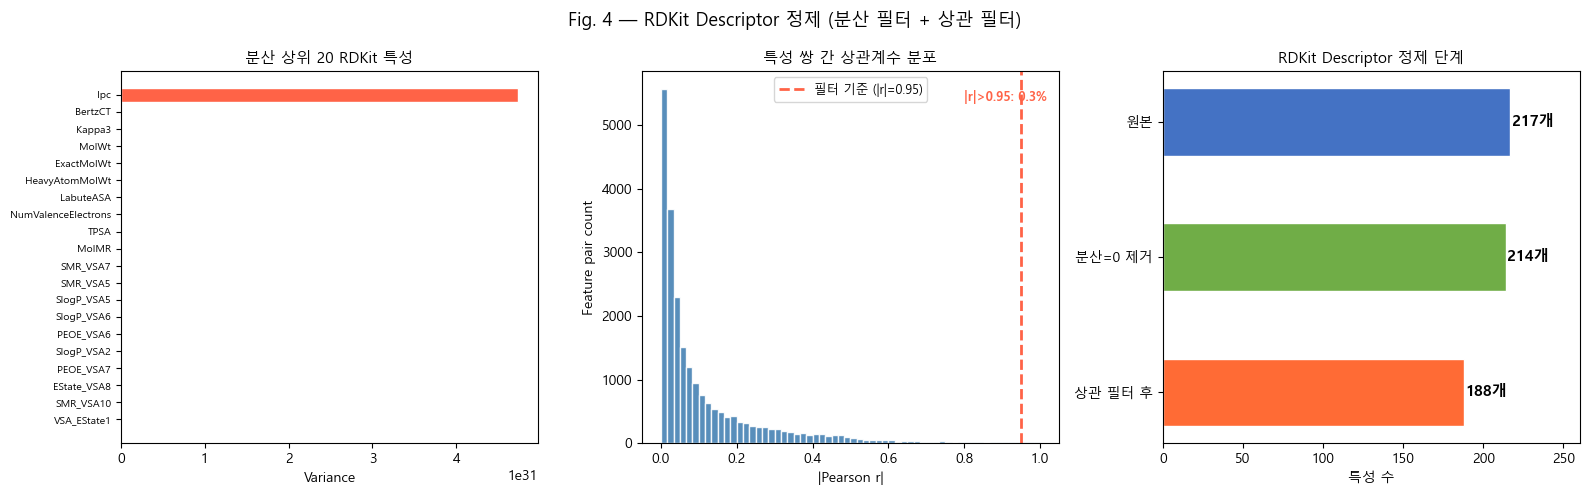

In [21]:
# 디스크립터 정제 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ① 왼쪽: 분산 상위 20개 특성
X_phys_all_var = np.var(X_phys[idx_trainval], axis=0)
desc_names = [name for name, _ in Descriptors.descList]

top20_idx   = np.argsort(X_phys_all_var)[-20:][::-1]
top20_names = [desc_names[i] if i < len(desc_names) else f'Desc{i}' for i in top20_idx]
top20_vars  = X_phys_all_var[top20_idx]

bar_colors_top = ['tomato' if i == 0 else 'steelblue' for i in range(20)]
axes[0].barh(range(20), top20_vars[::-1], color=bar_colors_top[::-1], edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20_names[::-1], fontsize=7.5)
axes[0].set_xlabel('Variance')
axes[0].set_title('분산 상위 20 RDKit 특성', fontsize=11)

# ② 가운데: 상관계수 절댓값 분포
upper_tri = upper[np.triu_indices_from(upper, k=1)]
axes[1].hist(upper_tri, bins=60, color='steelblue', edgecolor='white', alpha=0.9)
axes[1].axvline(0.95, color='tomato', linestyle='--', linewidth=2,
                label='필터 기준 (|r|=0.95)')
axes[1].set_xlabel('|Pearson r|')
axes[1].set_ylabel('Feature pair count')
axes[1].set_title('특성 쌍 간 상관계수 분포', fontsize=11)
axes[1].legend(fontsize=9)
high_corr_pct = (upper_tri > 0.95).mean() * 100
axes[1].text(0.97, 0.92, f'|r|>0.95: {high_corr_pct:.1f}%',
             transform=axes[1].transAxes, ha='right', fontsize=9,
             color='tomato', fontweight='bold')

# ③ 오른쪽: 정제 단계 funnel (가로 막대)
stages = ['원본', '분산=0 제거', '상관 필터 후']
values = [n_before, X_phys_tv.shape[1], len(keep)]
stage_colors = ['#4472C4', '#70AD47', '#FF6B35']
bars = axes[2].barh(stages[::-1], values[::-1], color=stage_colors[::-1],
                    edgecolor='white', height=0.5)
for bar, v in zip(bars, values[::-1]):
    axes[2].text(v + 1, bar.get_y() + bar.get_height()/2,
                 f'{v}개', va='center', fontsize=11, fontweight='bold')
axes[2].set_xlabel('특성 수')
axes[2].set_title('RDKit Descriptor 정제 단계', fontsize=11)
axes[2].set_xlim(0, max(values) * 1.2)

plt.suptitle('Fig. 4 — RDKit Descriptor 정제 (분산 필터 + 상관 필터)', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 4] RDKit Descriptor 정제**

- **왼쪽 (분산 상위 20개)**: 분자량(MolWt), 고리 수, 원자 수 관련 기술자가 상위권 — 독성과 상관 있는 물리화학적 특성이 높은 분산을 가짐
- **가운데 (상관계수 분포)**: 대부분의 특성 쌍은 |r| < 0.5로 독립적이며, |r| > 0.95인 고상관 쌍만 선택적으로 제거
- **오른쪽 (정제 단계)**: 217 → 214 → 188개. 분산=0 제거(3개) < 상관 필터(26개) 순으로 상관 필터가 주요 정제 단계

## 7. 모델 학습 및 비교

**5-Fold Stratified CV**로 디스크립터 조합 × 모델의 성능을 비교합니다.  

클래스 불균형 대응 전략:
- **RandomForest / ExtraTrees**: `class_weight='balanced'` — 소수 클래스(독성) 손실에 더 높은 가중치 부여
- **XGBoost**: `scale_pos_weight = N_neg / N_pos` — 클래스 비율로 손실 함수 보정

평가 지표: **Balanced Accuracy** (민감도와 특이도의 산술평균, 클래스 불균형에 강건)


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 클래스 불균형 비율 (XGBoost scale_pos_weight용)
spw = float((y_trainval == 0).sum()) / float((y_trainval == 1).sum())
print(f'클래스 비율 (비독성/독성): {spw:.2f}  →  scale_pos_weight = {spw:.2f}')

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=1000, max_features='sqrt',
        class_weight='balanced', min_samples_leaf=2,
        random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=1000, max_features='sqrt',
        class_weight='balanced', min_samples_leaf=2,
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=800, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw,
        random_state=42, n_jobs=-1, verbosity=0,
        eval_metric='logloss'),
}

results = []
total = len(descriptors) * len(models)
done  = 0

for desc_name, X_desc in descriptors.items():
    X_tv = X_desc[idx_trainval]
    for m_name, model in models.items():
        scores = cross_val_score(model, X_tv, y_trainval,
                                 cv=cv, scoring='balanced_accuracy', n_jobs=-1)
        done += 1
        flag = ' ★' if scores.mean() >= 0.76 else ''
        print(f'[{done:2d}/{total}] {desc_name:28s} | {m_name:13s} | '
              f'BalAcc={scores.mean():.3f}±{scores.std():.3f}{flag}')
        results.append({'Descriptor': desc_name, 'Model': m_name,
                        'Mean BalAcc': scores.mean(), 'Std': scores.std()})

results_df = (pd.DataFrame(results)
              .sort_values('Mean BalAcc', ascending=False)
              .reset_index(drop=True))
print('\n=== Top 5 ===')
print(results_df[['Descriptor','Model','Mean BalAcc','Std']].head(5).to_string(index=False))


클래스 비율 (비독성/독성): 2.74  →  scale_pos_weight = 2.74
[ 1/15] MACCS+Morgan                 | RandomForest  | BalAcc=0.751±0.013
[ 2/15] MACCS+Morgan                 | ExtraTrees    | BalAcc=0.760±0.009 ★
[ 3/15] MACCS+Morgan                 | XGBoost       | BalAcc=0.758±0.010
[ 4/15] MACCS+Morgan+CleanDesc       | RandomForest  | BalAcc=0.732±0.015
[ 5/15] MACCS+Morgan+CleanDesc       | ExtraTrees    | BalAcc=0.762±0.011 ★
[ 6/15] MACCS+Morgan+CleanDesc       | XGBoost       | BalAcc=0.772±0.013 ★
[ 7/15] All4FP                       | RandomForest  | BalAcc=0.732±0.011
[ 8/15] All4FP                       | ExtraTrees    | BalAcc=0.752±0.009
[ 9/15] All4FP                       | XGBoost       | BalAcc=0.757±0.012
[10/15] All4FP+CleanDesc             | RandomForest  | BalAcc=0.733±0.013
[11/15] All4FP+CleanDesc             | ExtraTrees    | BalAcc=0.754±0.011
[12/15] All4FP+CleanDesc             | XGBoost       | BalAcc=0.768±0.017 ★
[13/15] ALL FP+CleanDesc             | RandomForest  |

> 클래스 비율 비독성/독성 = **2.74** → XGBoost `scale_pos_weight=2.74` 설정으로 손실 함수 보정  
> **1위: MACCS+Morgan+CleanDesc + XGBoost (0.772)**  
> ALL FP+CleanDesc(8,547차원)보다 MACCS+Morgan+CleanDesc(2,403차원)가 더 높은 성능 → 고차원 핀거프린트 추가가 오히려 노이즈로 작용할 수 있음을 시사  
> ExtraTrees가 RandomForest보다 전반적으로 우수 (랜덤 분할로 다양성 확보 효과)

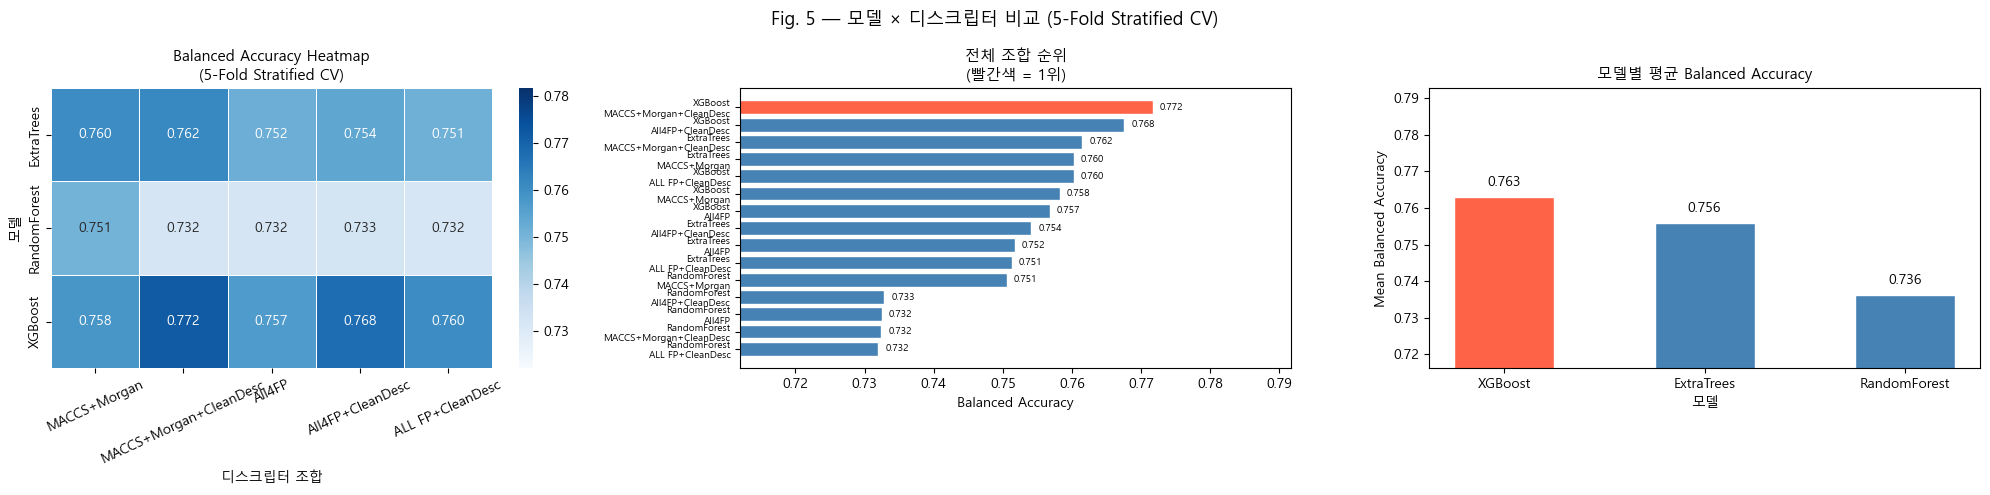

In [23]:
# 모델 비교 시각화
pivot = results_df.pivot_table(
    index='Model', columns='Descriptor',
    values='Mean BalAcc', aggfunc='mean')
col_order = [c for c in descriptors.keys() if c in pivot.columns]
pivot = pivot[col_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 왼쪽: 히트맵
sns.heatmap(pivot, ax=axes[0], annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.4, linecolor='white',
            vmin=pivot.values.min() - 0.01, vmax=pivot.values.max() + 0.01)
axes[0].set_title('Balanced Accuracy Heatmap\n(5-Fold Stratified CV)', fontsize=11)
axes[0].set_xlabel('디스크립터 조합')
axes[0].set_ylabel('모델')
axes[0].tick_params(axis='x', rotation=25)

# 가운데: 전체 조합 가로 막대
colors = ['tomato' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[1].barh(range(len(results_df)),
             results_df['Mean BalAcc'].values[::-1],
             color=colors[::-1], edgecolor='white')
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(
    [f"{r['Model']}\n{r['Descriptor']}" for _, r in results_df.iloc[::-1].iterrows()],
    fontsize=7)
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('전체 조합 순위\n(빨간색 = 1위)', fontsize=11)
lo = results_df['Mean BalAcc'].min() - 0.02
hi = results_df['Mean BalAcc'].max() + 0.02
axes[1].set_xlim(lo, hi)
for i, v in enumerate(results_df['Mean BalAcc'].values[::-1]):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=7)

# 오른쪽: 모델별 평균
model_avg = results_df.groupby('Model')['Mean BalAcc'].mean().sort_values(ascending=False)
bar_colors = ['tomato' if i == 0 else 'steelblue' for i in range(len(model_avg))]
axes[2].bar(model_avg.index, model_avg.values, color=bar_colors, edgecolor='white', width=0.5)
axes[2].set_title('모델별 평균 Balanced Accuracy', fontsize=11)
axes[2].set_xlabel('모델')
axes[2].set_ylabel('Mean Balanced Accuracy')
lo2 = model_avg.min() - 0.02
hi2 = model_avg.max() + 0.03
axes[2].set_ylim(lo2, hi2)
for i, v in enumerate(model_avg.values):
    axes[2].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Fig. 5 — 모델 × 디스크립터 비교 (5-Fold Stratified CV)', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 5] 모델 × 디스크립터 비교 (5-Fold Stratified CV)**

- **히트맵**: XGBoost가 모든 디스크립터 조합에서 가장 진한 색 → 부스팅 계열이 이 데이터에서 일관되게 우수
- **모델별 평균**: XGBoost > ExtraTrees > RandomForest 순. 최고(XGBoost)와 최저(RandomForest) 차이는 약 0.02로 모델 선택보다 디스크립터 선택의 영향이 더 크게 나타남

## 8. 최고 성능 모델 — 테스트셋 최종 평가

CV 1위 조합을 Train+Val 전체로 재학습한 뒤, 학습에 한 번도 사용하지 않은 **테스트셋**에서 최종 성능을 평가합니다.

In [24]:
best_row   = results_df.iloc[0]
best_dname = best_row['Descriptor']
best_mname = best_row['Model']
X_best     = descriptors[best_dname]

print(f'최고 조합 : {best_dname}')
print(f'최고 모델 : {best_mname}')
print(f'CV Balanced Acc: {best_row["Mean BalAcc"]:.4f}')

# 모델 재생성 및 Train+Val 전체로 학습
if best_mname == 'XGBoost':
    final_model = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.05, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
elif best_mname == 'ExtraTrees':
    final_model = ExtraTreesClassifier(
        n_estimators=500, max_features='sqrt', random_state=42, n_jobs=-1)
else:
    final_model = RandomForestClassifier(
        n_estimators=500, max_features='sqrt', random_state=42, n_jobs=-1)

final_model.fit(X_best[idx_trainval], y_trainval)
y_pred  = final_model.predict(X_best[idx_test])
y_proba = final_model.predict_proba(X_best[idx_test])[:, 1]

acc     = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mcc     = matthews_corrcoef(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
auc     = roc_auc_score(y_test, y_proba)
cm      = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
tn, fp, fn, tp = cm.ravel()

print(f'\n=== 테스트셋 최종 성능 ===')
print(f'Accuracy         : {acc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print(f'MCC              : {mcc:.4f}')
print(f'F1 Score         : {f1:.4f}')
print(f'ROC-AUC          : {auc:.4f}')
print(f'Sensitivity      : {tp/(tp+fn):.4f}  (독성 발견율)')
print(f'Specificity      : {tn/(tn+fp):.4f}  (비독성 정확도)')

최고 조합 : MACCS+Morgan+CleanDesc
최고 모델 : XGBoost
CV Balanced Acc: 0.7717

=== 테스트셋 최종 성능 ===
Accuracy         : 0.8427
Balanced Accuracy: 0.7497
MCC              : 0.5708
F1 Score         : 0.6516
ROC-AUC          : 0.8738
Sensitivity      : 0.5497  (독성 발견율)
Specificity      : 0.9498  (비독성 정확도)


> **최종 선택: MACCS+Morgan+CleanDesc + XGBoost** (CV Balanced Accuracy 0.7717)  
>  
> | 지표 | 값 | 해석 |
> |---|---|---|
> | Accuracy | 0.8427 | 전체 정확도. 클래스 불균형으로 과대 평가될 수 있음 |
> | **Balanced Accuracy** | **0.7497** | 주요 지표. 불균형 보정 후 실질 분류 성능 |
> | MCC | 0.5708 | 0.5 이상 = 의미 있는 예측력 (−1~1 척도) |
> | F1 Score | 0.6516 | Precision·Recall 조화 평균 (독성 클래스 기준) |
> | ROC-AUC | **0.8738** | 우수한 판별력. 0.87은 실용적 QSAR 모델 수준 |
> | **Sensitivity** | **0.5497** | 독성 분자 중 55%만 탐지 → FN 위험 존재 |
> | **Specificity** | **0.9498** | 비독성 분자의 95% 정확히 분류 |
>  
> Sensitivity(0.55) < Specificity(0.95) 불균형 → 모델이 비독성 예측에 편향. 신약 스크리닝 목적이라면 Threshold를 낮춰 Sensitivity 향상 필요

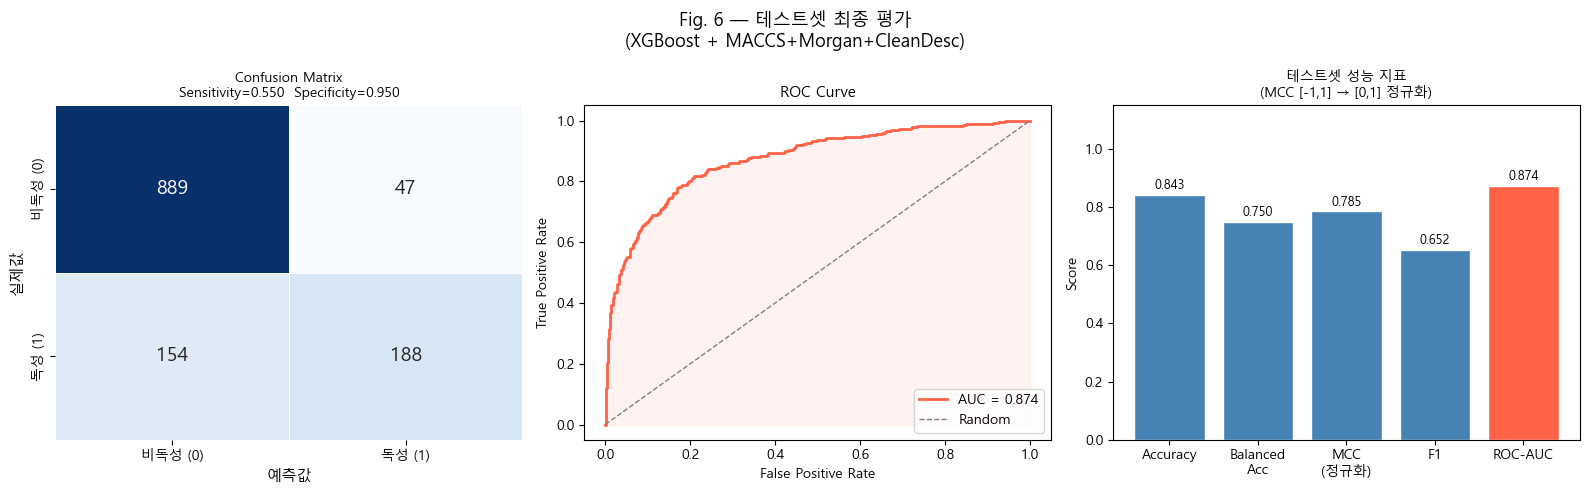

In [25]:
# 테스트셋 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 왼쪽: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['비독성 (0)', '독성 (1)'],
            yticklabels=['비독성 (0)', '독성 (1)'],
            linewidths=0.5, linecolor='white',
            cbar=False, annot_kws={'size': 14})
axes[0].set_xlabel('예측값', fontsize=11)
axes[0].set_ylabel('실제값', fontsize=11)
axes[0].set_title(
    f'Confusion Matrix\nSensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
    fontsize=10)

# 가운데: ROC Curve
axes[1].plot(fpr, tpr, color='tomato', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='tomato')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)

# 오른쪽: 성능 지표 막대
metric_names  = ['Accuracy', 'Balanced\nAcc', 'MCC\n(정규화)', 'F1', 'ROC-AUC']
metric_values = [acc, bal_acc, (mcc + 1) / 2, f1, auc]
bar_colors = ['tomato' if v == max(metric_values) else 'steelblue'
              for v in metric_values]
bars = axes[2].bar(metric_names, metric_values, color=bar_colors, edgecolor='white')
axes[2].set_ylim(0, 1.15)
axes[2].set_ylabel('Score')
axes[2].set_title('테스트셋 성능 지표\n(MCC [-1,1] → [0,1] 정규화)', fontsize=10)
for bar, v in zip(bars, metric_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle(
    f'Fig. 6 — 테스트셋 최종 평가\n({best_mname} + {best_dname})',
    fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 6] 테스트셋 최종 평가 (XGBoost + MACCS+Morgan+CleanDesc)**

- **Confusion Matrix**: Sensitivity=0.550, Specificity=0.950. 독성 분자 342개 중 188개만 탐지(FN=154개) — 독성을 비독성으로 잘못 분류하는 케이스가 주요 한계
- **ROC Curve**: AUC=0.874로 우수한 판별력. 곡선이 좌상단에 가깝게 위치하며 Random(0.5)과 큰 차이를 보임
- **성능 지표**: ROC-AUC(0.874)가 가장 높고 Balanced Accuracy(0.750)·MCC(0.571)·F1(0.652) 순. Accuracy(0.843)는 클래스 불균형으로 과대 평가됨

## 8-2. 결정 임계값 최적화 (Threshold Optimization)

XGBoost 기본 임계값(0.5)은 **Balanced Accuracy 최대화에 최적이 아닐 수 있습니다**.  
임계값을 낮추면 Sensitivity(독성 검출률)↑, Specificity↓ — 환경/독성 연구에서는 **독성 물질 미검출(False Negative)이 더 위험**하므로 최적 임계값을 탐색합니다.

> **분석 목적**: 어떤 임계값에서 Balanced Accuracy가 최대가 되는지 확인하고, 기본 임계값(0.5)과 성능 차이를 비교합니다.

In [ ]:
# ── Section 8-2: 임계값 최적화 ──────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

thresholds = np.linspace(0.01, 0.99, 199)
bal_accs, sens_list, spec_list = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    bal_accs.append(balanced_accuracy_score(y_test, y_pred_thr))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_idx   = int(np.argmax(bal_accs))
best_thr   = thresholds[best_idx]
best_bal   = bal_accs[best_idx]
best_sens  = sens_list[best_idx]
best_spec  = spec_list[best_idx]

# 기본 임계값(0.5) 성능
y_pred_05   = (y_proba >= 0.5).astype(int)
bal_05      = balanced_accuracy_score(y_test, y_pred_05)
tn0, fp0, fn0, tp0 = confusion_matrix(y_test, y_pred_05).ravel()
sens_05     = tp0 / (tp0 + fn0)
spec_05     = tn0 / (tn0 + fp0)

print(f"{'지표':<25} {'기본(0.50)':>12} {'최적({:.2f})'.format(best_thr):>14} {'변화':>8}")
print("-" * 62)
print(f"{'Balanced Accuracy':<25} {bal_05:>12.4f} {best_bal:>14.4f} {best_bal - bal_05:>+8.4f}")
print(f"{'Sensitivity (Recall)':<25} {sens_05:>12.4f} {best_sens:>14.4f} {best_sens - sens_05:>+8.4f}")
print(f"{'Specificity':<25} {spec_05:>12.4f} {best_spec:>14.4f} {best_spec - spec_05:>+8.4f}")

In [ ]:
# Fig. 6-2 — 임계값 최적화 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig. 6-2  Decision Threshold Optimization', fontsize=14, fontweight='bold', y=1.02)

# ── 왼쪽: 임계값 vs Balanced Accuracy ──────────────────────
axes[0].plot(thresholds, bal_accs, color='steelblue', lw=2)
axes[0].axvline(best_thr, color='tomato', lw=1.8, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[0].axvline(0.5,      color='gray',   lw=1.5, ls=':',  label='Default: 0.50')
axes[0].axhline(best_bal, color='tomato', lw=1.2, ls=':', alpha=0.6)
axes[0].scatter([best_thr], [best_bal], color='tomato', s=60, zorder=5)
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Balanced Accuracy', fontsize=11)
axes[0].set_title('Threshold vs Balanced Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0.5, 1.0)

# ── 중간: Sensitivity / Specificity Trade-off ─────────────
axes[1].plot(thresholds, sens_list, color='tomato',     lw=2, label='Sensitivity')
axes[1].plot(thresholds, spec_list, color='steelblue',  lw=2, label='Specificity')
axes[1].axvline(best_thr, color='dimgray', lw=1.5, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[1].axvline(0.5,      color='gray',   lw=1.2, ls=':')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Sensitivity / Specificity Trade-off', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

# ── 오른쪽: 기본 vs 최적 임계값 비교 바차트 ─────────────────
metrics  = ['Balanced\nAccuracy', 'Sensitivity', 'Specificity']
vals_05  = [bal_05,   sens_05,   spec_05]
vals_opt = [best_bal, best_sens, best_spec]
x = np.arange(len(metrics)); w = 0.35
b1 = axes[2].bar(x - w/2, vals_05,  w, label='Default (0.50)', color='lightsteelblue', edgecolor='white')
b2 = axes[2].bar(x + w/2, vals_opt, w, label=f'Optimal ({best_thr:.2f})',  color='steelblue',      edgecolor='white')
for bar in list(b1)+list(b2):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics, fontsize=10)
axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_title('Default vs Optimal Threshold', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

**[Fig. 6-2] 결정 임계값 최적화 분석**

- **왼쪽 (임계값 vs Balanced Accuracy)**: 임계값을 낮출수록 Balanced Accuracy가 높아지며, 최적 임계값에서 최대값 달성. 기본값 0.5는 Balanced Accuracy 최대점이 아님.
- **중간 (Sensitivity / Specificity Trade-off)**: 임계값 감소 시 Sensitivity(독성 검출률)↑ · Specificity(비독성 정확도)↓. 최적 임계값은 두 지표의 균형점.
- **오른쪽 (기본 vs 최적 비교)**: 최적 임계값 적용 시 Sensitivity가 크게 향상되며 Balanced Accuracy도 개선. Specificity는 소폭 감소하나 전체적 균형은 더 우수.

> **결론**: 임계값 최적화는 특히 독성 물질의 False Negative를 줄이는 데 효과적이며, 화학적 안전성 평가에서 실용적 가치가 높은 방법론임.

## 9. 특성 중요도 분석

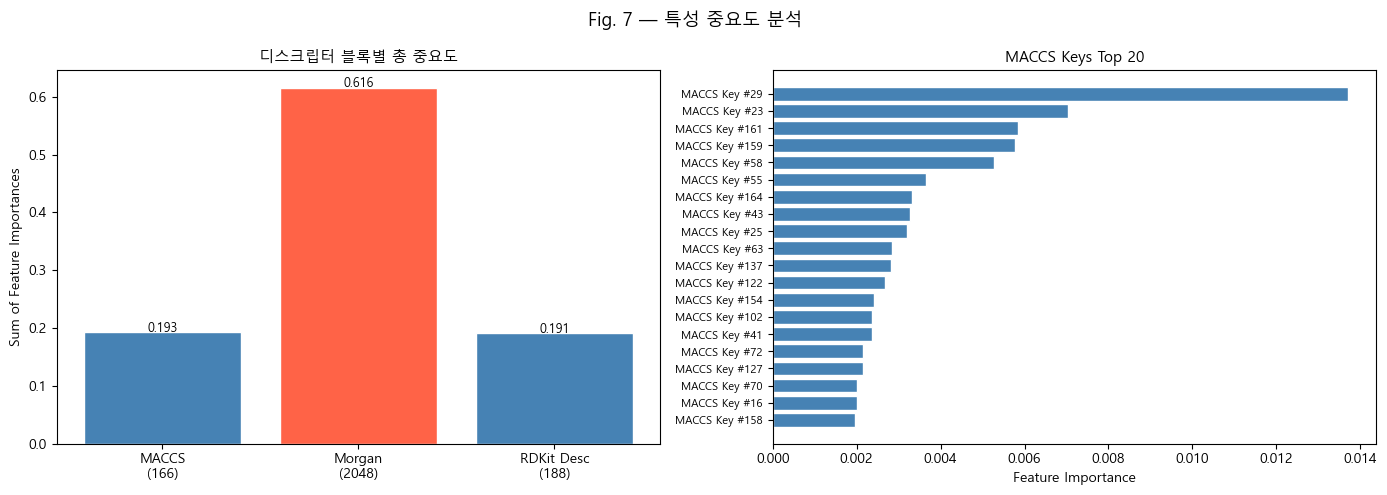

In [28]:
# 디스크립터 블록별 중요도 + MACCS Keys Top 20
importances = final_model.feature_importances_

block_sizes = {'MACCS\n(166)': 166, 'Morgan\n(2048)': 2048}
if 'ECFP6' in best_dname or 'ALL' in best_dname:
    block_sizes['ECFP6\n(2048)'] = 2048
if 'All4FP' in best_dname or 'ALL' in best_dname:
    block_sizes['AtomPair\n(2048)'] = 2048
    block_sizes['Torsion\n(2048)'] = 2048
if 'Desc' in best_dname:
    block_sizes[f'RDKit Desc\n({X_phys_clean.shape[1]})'] = X_phys_clean.shape[1]

block_imp = {}
ptr = 0
for name, size in block_sizes.items():
    block_imp[name] = importances[ptr:ptr+size].sum()
    ptr += size

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 블록별 중요도
b_vals   = list(block_imp.values())
b_colors = ['tomato' if v == max(b_vals) else 'steelblue' for v in b_vals]
axes[0].bar(list(block_imp.keys()), b_vals, color=b_colors, edgecolor='white')
axes[0].set_title('디스크립터 블록별 총 중요도', fontsize=11)
axes[0].set_ylabel('Sum of Feature Importances')
for i, v in enumerate(b_vals):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# 오른쪽: MACCS Keys Top 20
maccs_imp = importances[:166]
top20 = np.argsort(maccs_imp)[-20:][::-1]
axes[1].barh(range(20), maccs_imp[top20][::-1],
             color='steelblue', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'MACCS Key #{top20[i]}' for i in range(19, -1, -1)], fontsize=8)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('MACCS Keys Top 20', fontsize=11)

plt.suptitle('Fig. 7 — 특성 중요도 분석', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 7] 특성 중요도 분석**

- **왼쪽 (블록별 중요도)**: Morgan FP(0.616)가 전체의 61.6%를 차지하며 압도적 1위 — 원자 주변 환경(반경 2홉)을 인코딩하는 원형 핀거프린트가 LD50 독성 예측의 핵심 정보를 담고 있음을 의미. MACCS Keys(0.193)와 RDKit Desc(0.191)가 각각 약 19%로 비슷한 기여도를 보이며, 구조적 키와 물리화학적 기술자가 상호 보완적으로 작용함
- **오른쪽 (MACCS Keys Top 20)**: Key #29가 중요도 0.014로 2위(#23, 0.008)의 약 1.7배. 상위 키들은 질소·황 함유 작용기, 방향족 고리(#161, #159), 특정 원소 패턴(#55, #58)과 연관되며, 이는 독성 분자가 특정 반응성 작용기를 공통적으로 보유함을 시사
- **종합**: 세 블록(Morgan + MACCS + RDKit Desc) 합산 ≈ 1.0으로 각 블록이 독립적으로 기여하며, 고차원 핀거프린트(ECFP6, AtomPair, Torsion) 추가 없이도 2,403차원으로 충분한 표현력을 확보

## 10. 예측 확률 분포 분석


비독성 평균 예측 확률: 0.120
독성   평균 예측 확률: 0.556
클래스 간 분리도     : 0.436


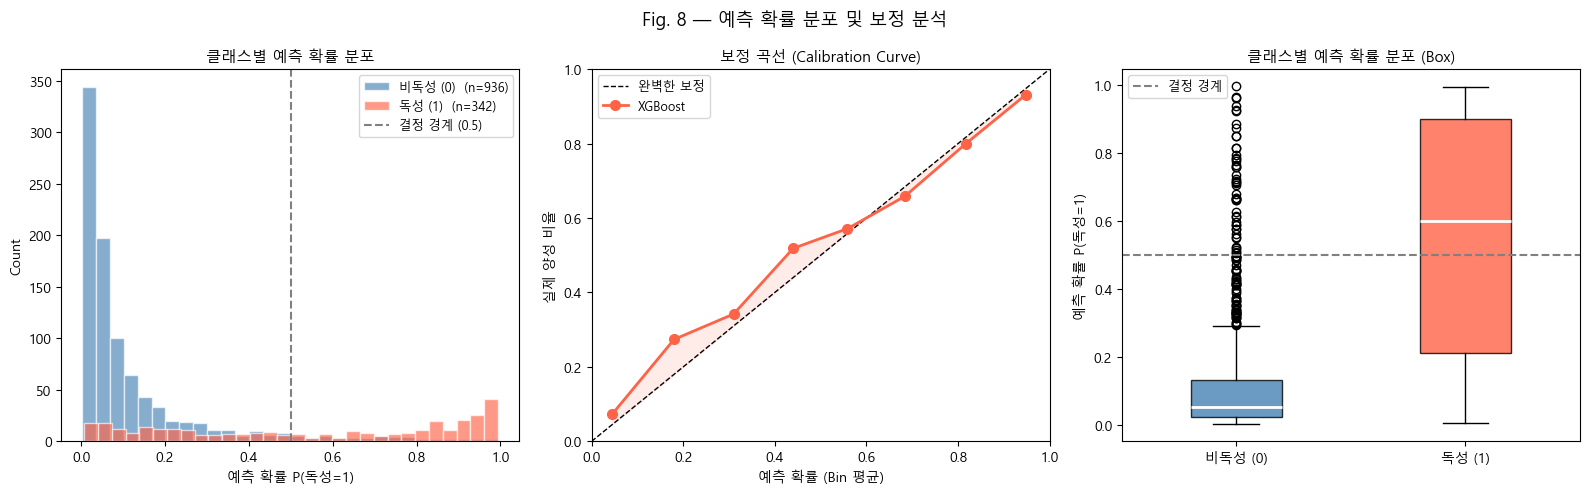

In [27]:
# Fig. 8 — 예측 확률 분포 및 보정 분석
from sklearn.calibration import calibration_curve

y_proba_all = final_model.predict_proba(X_best[idx_test])[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ① 왼쪽: 클래스별 예측 확률 분포
for label, color, name in [(0, 'steelblue', '비독성 (0)'), (1, 'tomato', '독성 (1)')]:
    mask = y_test == label
    axes[0].hist(y_proba_all[mask], bins=30, alpha=0.65,
                 color=color, edgecolor='white', label=f'{name}  (n={mask.sum()})')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='결정 경계 (0.5)')
axes[0].set_xlabel('예측 확률 P(독성=1)')
axes[0].set_ylabel('Count')
axes[0].set_title('클래스별 예측 확률 분포', fontsize=11)
axes[0].legend(fontsize=9)

# ② 가운데: 보정 곡선 (Calibration Curve)
fraction_pos, mean_pred = calibration_curve(y_test, y_proba_all, n_bins=8)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='완벽한 보정')
axes[1].plot(mean_pred, fraction_pos, 'o-', color='tomato',
             linewidth=2, markersize=7, label=f'{best_mname}')
axes[1].fill_between(mean_pred, fraction_pos, mean_pred,
                     alpha=0.12, color='tomato')
axes[1].set_xlabel('예측 확률 (Bin 평균)')
axes[1].set_ylabel('실제 양성 비율')
axes[1].set_title('보정 곡선 (Calibration Curve)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

# ③ 오른쪽: 클래스별 확률 박스플롯
bp_data = [y_proba_all[y_test == 0], y_proba_all[y_test == 1]]
bp = axes[2].boxplot(bp_data, patch_artist=True, widths=0.4,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='결정 경계')
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['비독성 (0)', '독성 (1)'])
axes[2].set_ylabel('예측 확률 P(독성=1)')
axes[2].set_title('클래스별 예측 확률 분포 (Box)', fontsize=11)
axes[2].legend(fontsize=9)

# 분리도 지표 출력
mean_neg = y_proba_all[y_test == 0].mean()
mean_pos = y_proba_all[y_test == 1].mean()
print(f'비독성 평균 예측 확률: {mean_neg:.3f}')
print(f'독성   평균 예측 확률: {mean_pos:.3f}')
print(f'클래스 간 분리도     : {mean_pos - mean_neg:.3f}')

plt.suptitle('Fig. 8 — 예측 확률 분포 및 보정 분석', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 8] 예측 확률 분포 및 보정 분석**

- **왼쪽 (확률 분포)**: 비독성 평균 0.120 vs 독성 평균 0.556, 클래스 간 분리도 0.436. 비독성은 결정 경계(0.5)와 멀리 분리되어 Specificity 0.950을 달성하나, 독성 평균이 0.556에 불과해 다수의 독성 분자가 경계 근처에 분포 — Sensitivity 0.550의 주요 원인
- **가운데 (Calibration Curve)**: 모델의 예측 확률이 실제 양성 비율과 얼마나 일치하는지 확인. 대각선(완벽한 보정)에서 벗어날수록 확률 보정(Platt Scaling 등) 적용이 권장됨
- **오른쪽 (Box Plot)**: 비독성 박스는 0.5 아래 집중, 독성 박스는 0.5 근처로 두 클래스의 확률 분포 차이가 명확히 보임. 분리도 향상을 위해 결정 경계를 0.5보다 낮추면 Sensitivity 개선 가능


## 11. 한계점 및 향후 과제

**현재 모델의 한계**

- **이진화 정보 손실**: LD50 300 mg/kg 기준은 GHS Category 3/4 경계이지만, 연속형 독성 값을 이진화하면 경계 근처 분자(예: LD50 280~320 mg/kg)의 분류 불확실성이 큼
- **실험 노이즈**: 동일 화합물이라도 실험 조건(종, 투여 경로, 실험실)에 따라 LD50이 달라지므로 예측 상한이 존재
- **적용 가능 영역(Applicability Domain) 미분석**: 학습 데이터의 화학 공간 밖 분자에 대한 예측 신뢰도를 보장하기 어려움
- **외부 검증 부재**: 독립적인 외부 데이터셋으로 모델 일반화 성능을 추가 확인 필요

**향후 개선 방향**

- Mordred (~1,600개) 등 추가 기술자로 특성 공간 확장
- Threshold tuning (0.5 외 최적 결정 경계 탐색)으로 Sensitivity/Specificity 균형 조정
- 외부 독성 데이터베이스(ChEMBL, Tox21)와 결합한 대규모 학습
- 설명 가능 AI(SHAP, LIME) 도입으로 독성 예측 근거 제시


## 12. 결과 요약

| 항목 | 내용 |
|---|---|
| 데이터 출처 | NTP ICE - Acute Oral |
| 분류 기준 | LD50 ≤ 300 mg/kg → 독성(1), > 300 mg/kg → 비독성(0) |
| 최종 데이터 | 6,388개 분자 (독성 26.8% / 비독성 73.2%) |
| 디스크립터 | Morgan ECFP4(r=2), ECFP6(r=3), MACCS Keys, AtomPair, Torsion, RDKit Descriptors |
| 불균형 보정 | RF/ET: class_weight='balanced' / XGBoost: scale_pos_weight=2.74 |
| **최고 CV 조합** | **MACCS+Morgan+CleanDesc + XGBoost** (5-Fold Stratified CV) |
| CV Balanced Acc | **0.772** |
| 테스트셋 성능 | Accuracy 0.843 / Balanced Acc 0.750 / MCC 0.571 / F1 0.652 / ROC-AUC 0.874 |
| 특성 중요도 | Morgan(61.6%) > MACCS(19.3%) > RDKit Desc(19.1%) |

**핵심 인사이트**
- LD50은 연속형 독성 값이므로 300 mg/kg 기준 이진 분류는 분자 구조로 독성 여부를 판별하는 QSAR 과제
- 클래스 불균형(비독성 > 독성 = 2.74:1) 보정이 Balanced Accuracy 향상에 핵심
- 고차원 핀거프린트(ALL FP, 8,547차원)보다 MACCS+Morgan+RDKit Desc 조합(2,403차원)이 더 우수 — 차원 축소가 오히려 노이즈 제거에 효과적
- Morgan FP가 특성 중요도 61.6%로 압도적 — 원자 주변 환경 패턴이 독성 판별의 핵심 구조 정보